In [14]:
import sys
sys.path.append("/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/")
from skew_correction import full_correction

import numpy as np
import os 
import sys
import astropy.units as u
import astropy.constants as const
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from concurrent.futures import ProcessPoolExecutor
import concurrent
import concurrent.futures
from astropy.visualization import ImageNormalize, AsinhStretch
from juanfit import gaussian
from plotting_modules import doppler_plot, amplitude_plot
from skew_parameter_search import detrend_dopp
from fancy_colorbar import plot_colorbar
from matplotlib.patches import Rectangle
from spec_add_time_wcs import add_temporal_axis
from clean_spice_celestial_header import remove_temporal_axis


from matplotlib.animation import FuncAnimation
from astropy.visualization import (ImageNormalize, AsinhStretch,
                                   ) 
from IPython.display import HTML, display

from matplotlib import rcParams
rcParams['image.interpolation'] = 'none'

In [2]:
spice_file = "~/work/spice_psf/spice_data/solo_L2_spice-n-ras_20221029T191144_V22_150995443-048.fits"

with fits.open(spice_file) as hdul:
    hdul.info()
    spice_NeVIII_data = hdul[2].data[0].copy()
    spice_NeVIII_header = hdul[2].header.copy()
    spice_CIII_data = hdul[3].data[0].copy()
    spice_CIII_header = hdul[3].header.copy()
spice_NeVIII_data = spice_NeVIII_data.T
spice_CIII_data = spice_CIII_data.T
# spice_NeVIII_header["NAXIS1"] = 60
# spice_NeVIII_header["NAXIS2"] = 240
# spice_NeVIII_data = spice_NeVIII_data[30:90,240:480,:]

Filename: /cluster/home/zhuyin/work/spice_psf/spice_data/solo_L2_spice-n-ras_20221029T191144_V22_150995443-048.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  O III 703 / Mg IX 706 (Merged)    1 PrimaryHDU     426   (128, 832, 40, 1)   float32   
  1  Fe XX 721 + O II (Merged)    1 ImageHDU       427   (128, 832, 40, 1)   float32   
  2  N IV 765 - SH - Comp 8 ... Ne VIII 770 - LH - Comp 8 (Merged)    1 ImageHDU       427   (128, 832, 72, 1)   float32   
  3  Ly-gamma-CIII group (Merged)    1 ImageHDU       427   (128, 832, 60, 1)   float32   
  4  Ly Beta 1025 (Merged)    1 ImageHDU       427   (128, 832, 31, 1)   float32   
  5  O VI 1032 (Merged)    1 ImageHDU       427   (128, 832, 31, 1)   float32   
  6  VARIABLE_KEYWORDS    1 BinTableHDU    385   1R x 27C   [128D, 128I, 128I, 128I, 128I, 128I, 128E, 128E, 128E, 128E, 4I, 4I, 4I, 4I, 4J, 4J, 4J, 4J, 2944A, 128D, 128D, 40D, 40D, 72D, 60D, 31D, 31D]   
  7  WCSDVARR      1 ImageHDU        28   (128,)   float

In [3]:
spice_NeVIII_data.shape, 
spice_CIII_data.shape

(128, 832, 60)

In [4]:
NeVIII_wvl = spice_NeVIII_header["CRVAL3"] + \
spice_NeVIII_header["CDELT3"] * (np.arange(1, spice_NeVIII_header["NAXIS3"]+1) - spice_NeVIII_header["CRPIX3"])
NeVIII_wvl = NeVIII_wvl*10
CIII_wvl = spice_CIII_header["CRVAL3"] + \
spice_CIII_header["CDELT3"] * (np.arange(1, spice_CIII_header["NAXIS3"]+1) - spice_CIII_header["CRPIX3"])
CIII_wvl = CIII_wvl*10

In [5]:
load_data = False

In [8]:
if not load_data:
    raw_results_CIII = full_correction(spice_CIII_data, spice_CIII_header, 0, 0, nthreads=12, linelist={'C III 977':977.0},
                                       impulse_filter=True)
else:
    with np.load("/cluster/home/zhuyin/work/spice_psf/spice_skew_20221029/raw_CIII_results_20221029T191144.npz", allow_pickle=True) as f:
        raw_results_CIII = dict(f)

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


In [23]:
if not load_data:
    raw_results_NeVIII = full_correction(spice_NeVIII_data, spice_NeVIII_header, 0, 0, nthreads=12, linelist={'Ne VIII 770':770.4})
else:
    with np.load("/cluster/home/zhuyin/work/spice_psf/spice_skew_20221029/raw_NeVIII_results_20221029T191144.npz", allow_pickle=True) as f:
        raw_results_NeVIII = dict(f)

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


In [15]:
def correction_preview(best_correction_results, load_data=load_data, xlim=None, ylim=None):
    if load_data:
        plt_linefits = best_correction_results['linefits'].item()
    else:
        plt_linefits = best_correction_results['linefits']
    ymin,ymax = best_correction_results['ymin'],best_correction_results['ymax']
    line_name = list(plt_linefits[0].keys())[0]
    date = plt_linefits[0][0]['amplitudes'].meta['DATE-OBS']

    fig=plt.figure(figsize=[16,8])
    gs = fig.add_gridspec(nrows=2,ncols=2,width_ratios=[1,1],height_ratios=[7,1])
    cbaxes = [fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]
    axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]

    plt.suptitle('Corrected fits for '+line_name+' at '+date)
    amplitude_plot(plt_linefits[0][0],axis=axes[0], cbaxis=cbaxes[0], ymin=ymin, ymax=ymax)
    doppler_plot(plt_linefits[0][0],axis=axes[1], cbaxis=cbaxes[1], doppmin=-0.075, doppmax=0.075, ymin=ymin,ymax=ymax)
    axes[1].set(title='Doppler; best xshift, yshift='+str(best_correction_results['xlshift'])+','+str(best_correction_results['ylshift']))

    if xlim is not None:
        for ax_ in axes:
            ax_.set_xlim(xlim)
    if ylim is not None:
        for ax_ in axes:
            ax_.set_ylim(ylim)

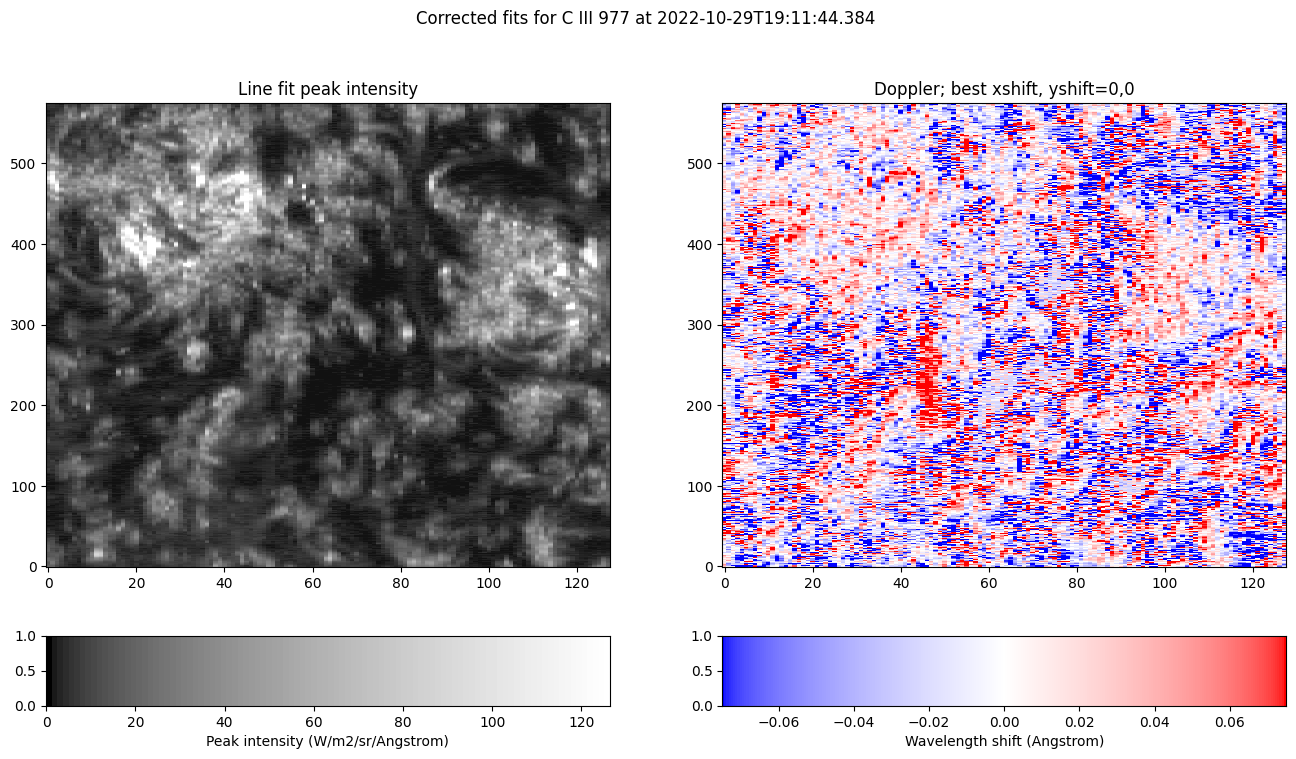

In [16]:
correction_preview(raw_results_CIII)

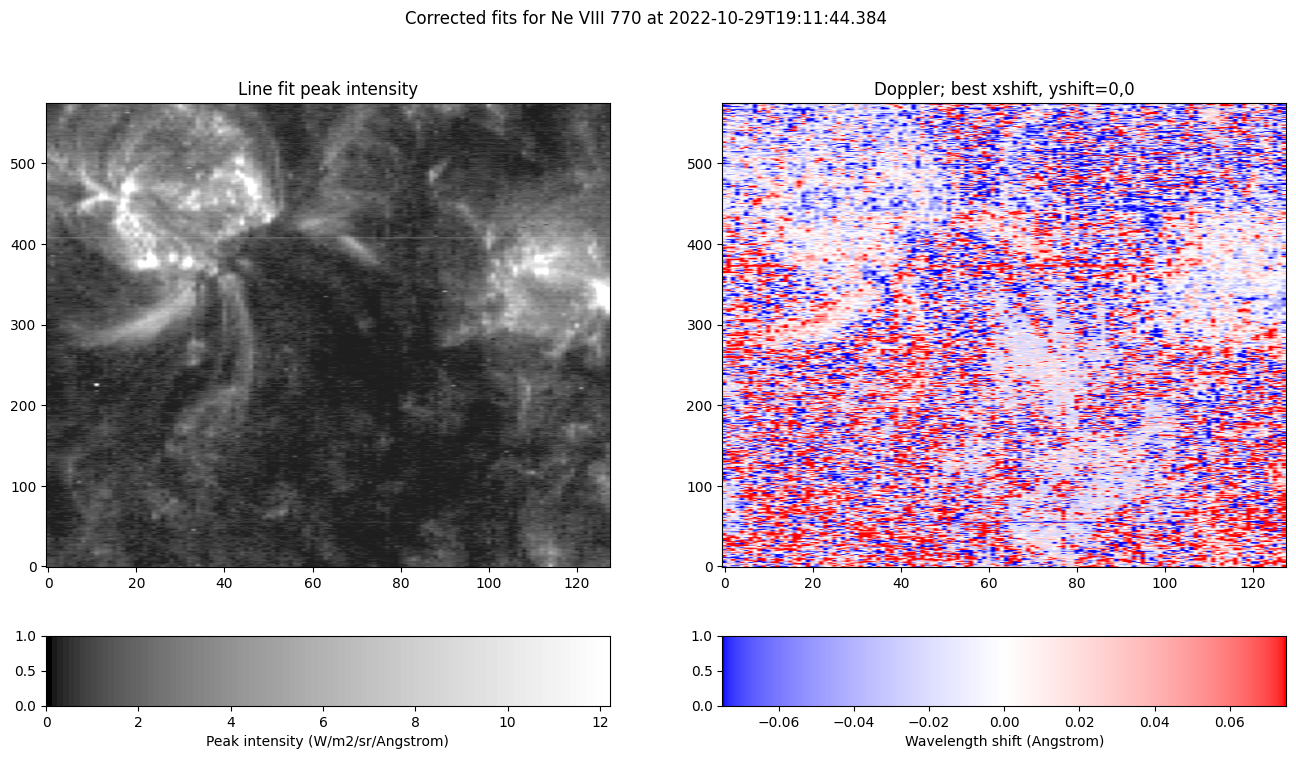

In [29]:
correction_preview(raw_results_NeVIII)

In [25]:
best_skew_x_CIII, best_skew_y_CIII = 1.22, -1.

if not load_data:
    best_correction_results_CIII = full_correction(spice_CIII_data, spice_CIII_header, best_skew_x_CIII, best_skew_y_CIII, nthreads=12,
                                               linelist={'C III 977':977.0}, impulse_filter=True)
else:
    with np.load("/cluster/home/zhuyin/work/spice_psf/spice_skew_20221029/best_CIII_results_20221029T191144.npz", allow_pickle=True) as f:
        best_correction_results_CIII = dict(f)

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


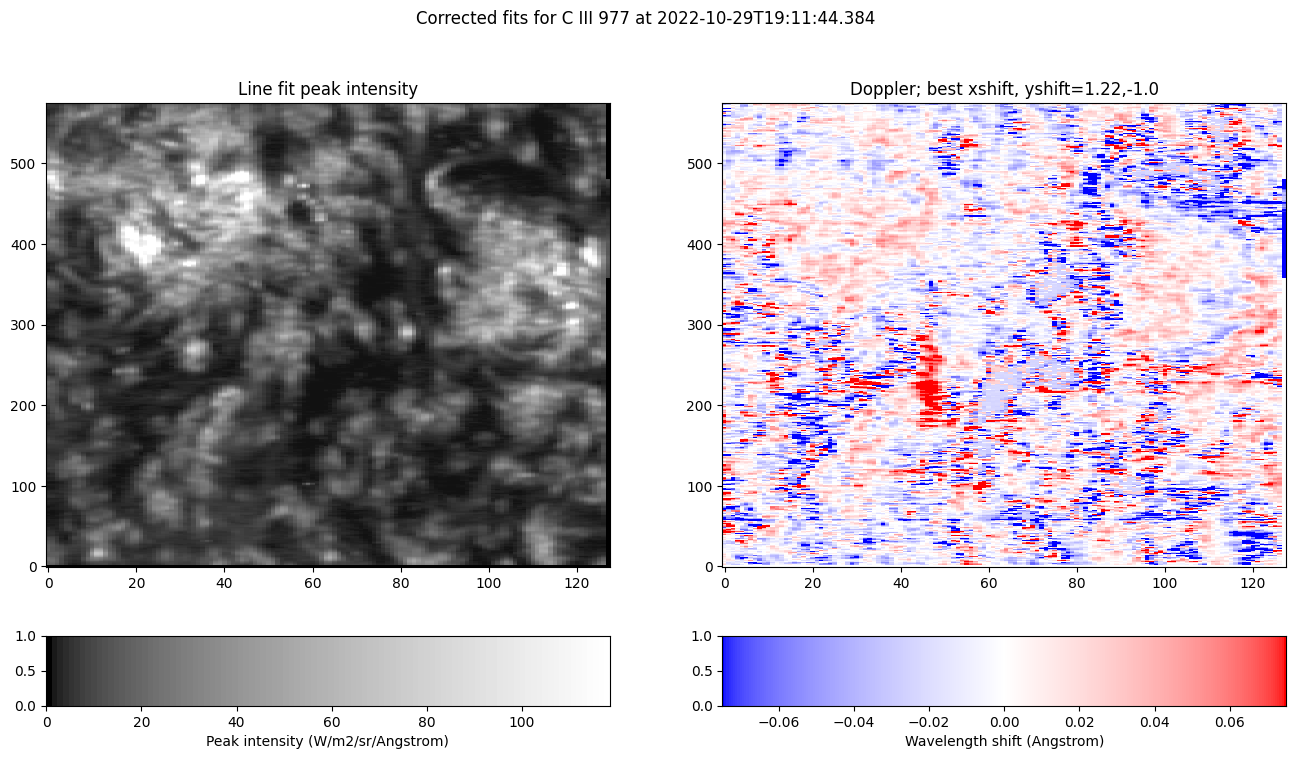

In [26]:
correction_preview(best_correction_results_CIII)

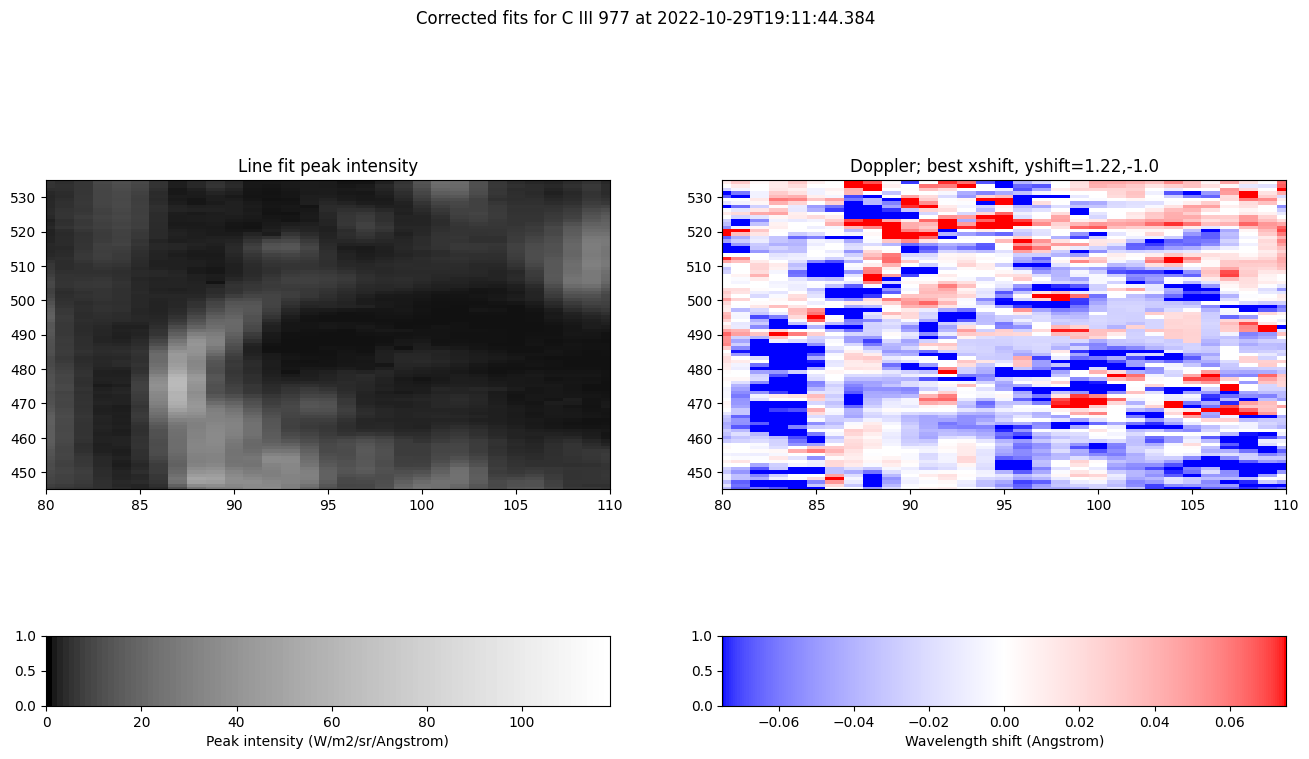

In [27]:
correction_preview(best_correction_results_CIII, xlim=(80,80+30),ylim=(445,445+90))

In [23]:
def test_best_corr(data, header, skew_x, skew_y, linelist):
    best_correction_results = full_correction(data, header, skew_x, skew_y, nthreads=12,
                                               linelist=linelist)
    
    correction_preview(best_correction_results)

    return best_correction_results

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


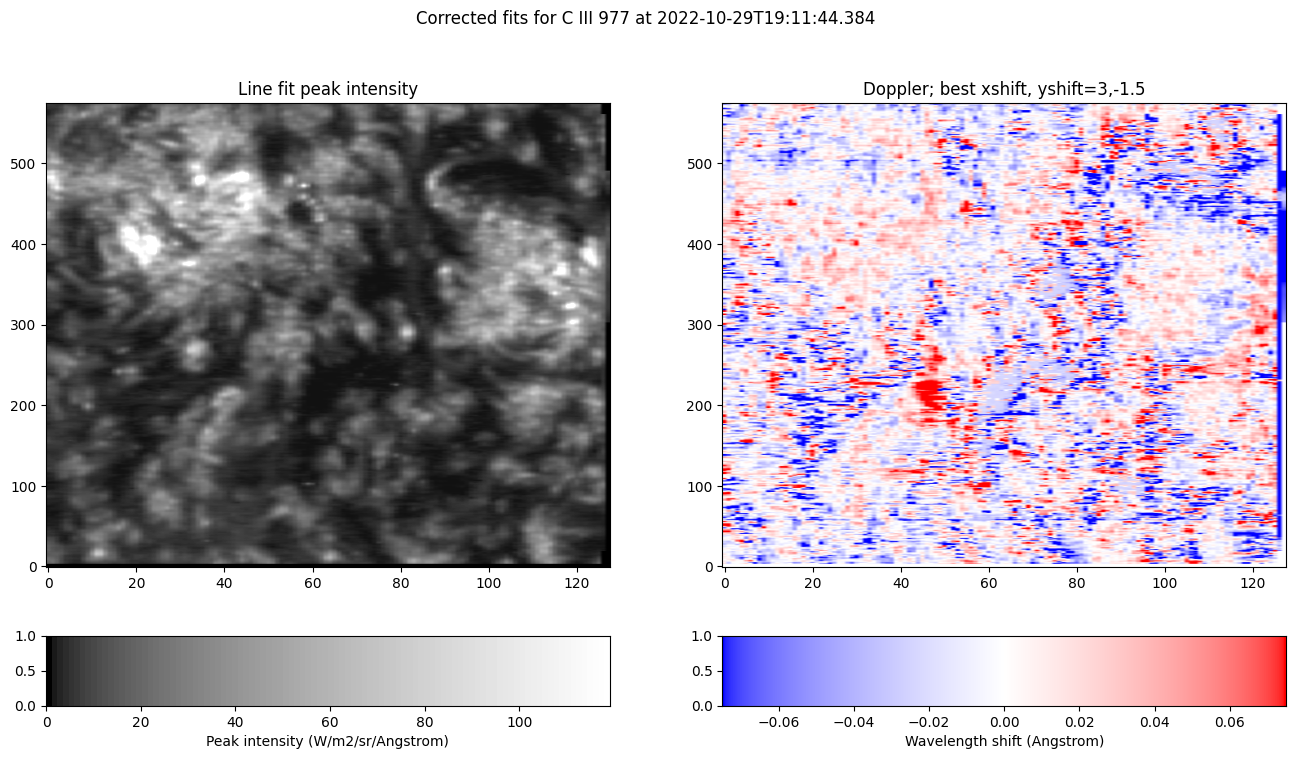

In [24]:
_ = test_best_corr(spice_CIII_data, spice_CIII_header, 3, -1.5,
               linelist={'C III 977':977.0})

In [31]:
best_skew_x_NeVIII, best_skew_y_NeVIII = 2.44444, 0.2222

if not load_data:
    best_correction_results_NeVIII = full_correction(spice_NeVIII_data, spice_NeVIII_header, best_skew_x_NeVIII, best_skew_y_NeVIII, nthreads=12,
                                                linelist={'Ne VIII 770':770.4})
else:
    with np.load("/cluster/home/zhuyin/work/spice_psf/spice_skew_20221029/best_NeVIII_results_20221029T191144.npz", allow_pickle=True) as f:
        best_correction_results_NeVIII = dict(f)

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


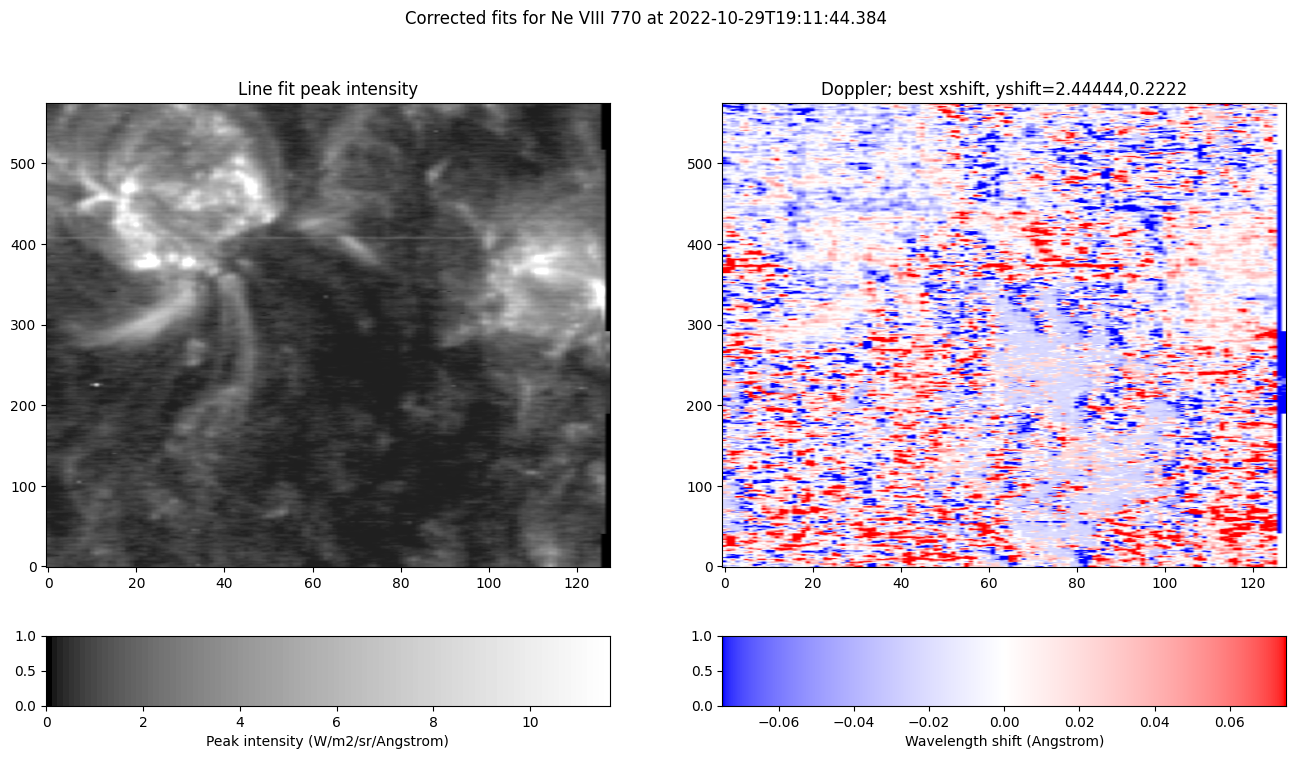

In [32]:
correction_preview(best_correction_results_NeVIII)

In [28]:
if not load_data:
    np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20221029/raw_CIII_results_20221029T191144.npz", **raw_results_CIII)
    # np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20221029/raw_NeVIII_results_20221029T191144.npz", **raw_results_NeVIII)
    np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20221029/best_CIII_results_20221029T191144.npz", **best_correction_results_CIII)
    # np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20221029/best_NeVIII_results_20221029T191144.npz", **best_correction_results_NeVIII)

In [19]:
raw_results_CIII.keys()

dict_keys(['dat_skew', 'err_skew', 'linefits', 'xlshift', 'ylshift', 'kwargs', 'hdr', 'centers', 'lines', 'mask', 'waves', 'offsets', 'ymin', 'ymax'])

In [29]:
if not load_data:
    raw_CIII_int = raw_results_CIII['linefits']['Ly-gamma-CIII group (Merged)']['C III 977']['amplitudes'].data[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T
    raw_CIII_vel = detrend_dopp(raw_results_CIII['linefits']['Ly-gamma-CIII group (Merged)']['C III 977']['centers'])[:,raw_results_CIII['ymin']:raw_results_CIII['ymax']].T
    raw_CIII_vel_err = raw_results_CIII['linefits']['Ly-gamma-CIII group (Merged)']['C III 977']['centers'].uncertainty.array[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T


    skew_CIII_int = best_correction_results_CIII['linefits']['Ly-gamma-CIII group (Merged)']['C III 977']['amplitudes'].data[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T
    skew_CIII_vel = detrend_dopp(best_correction_results_CIII['linefits']['Ly-gamma-CIII group (Merged)']['C III 977']['centers'])[:,raw_results_CIII['ymin']:raw_results_CIII['ymax']].T
    skew_CIII_vel_err = best_correction_results_CIII['linefits']['Ly-gamma-CIII group (Merged)']['C III 977']['centers'].uncertainty.array[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T

else:
    raw_CIII_linefits = raw_results_CIII['linefits'].item()
    raw_results_CIII_ymin = raw_results_CIII['ymin'].item()
    raw_results_CIII_ymax = raw_results_CIII['ymax'].item()

    raw_CIII_int = raw_CIII_linefits[0][0]['amplitudes'].data[:,raw_results_CIII_ymin:raw_results_CIII_ymax,0,0].T
    raw_CIII_vel = detrend_dopp(raw_CIII_linefits[0][0]['centers'])[:,raw_results_CIII_ymin:raw_results_CIII_ymax].T
    raw_CIII_vel_err = raw_CIII_linefits[0][0]['centers'].uncertainty.array[:,raw_results_CIII_ymin:raw_results_CIII_ymax,0,0].T

    skew_CIII_linefits = best_correction_results_CIII['linefits'].item()

    skew_CIII_int = skew_CIII_linefits[0][0]['amplitudes'].data[:,raw_results_CIII_ymin:raw_results_CIII_ymax,0,0].T
    skew_CIII_vel = detrend_dopp(skew_CIII_linefits[0][0]['centers'])[:,raw_results_CIII_ymin:raw_results_CIII_ymax].T
    skew_CIII_vel_err = skew_CIII_linefits[0][0]['centers'].uncertainty.array[:,raw_results_CIII_ymin:raw_results_CIII_ymax,0,0].T    


raw_CIII_vel_mask = np.abs(raw_CIII_vel_err) > 0.025
raw_CIII_vel[raw_CIII_vel_mask] = np.nan
raw_CIII_vel = raw_CIII_vel - np.nanmedian(raw_CIII_vel[:200, :40]) 
raw_CIII_vel = raw_CIII_vel/977.020*const.c.to_value(u.km/u.s) # + 7.5 # from Xia et al. (2004)

skew_CIII_vel_mask = np.abs(skew_CIII_vel_err) > 0.025
skew_CIII_vel[skew_CIII_vel_mask] = np.nan
skew_CIII_vel = skew_CIII_vel - np.nanmedian(skew_CIII_vel[:200, :40]) 
skew_CIII_vel = skew_CIII_vel/977.020*const.c.to_value(u.km/u.s) + 5


In [18]:
def play_data(data, aspect=1, vmin_perc=0.5, vmax_perc=99.5, fps=3, save_filename=None):
    nx, ny, nl = data.shape

    fig, ax = plt.subplots(1,1,figsize=(6,6))
    im = ax.imshow(data[:,:,0].T, aspect=aspect, interpolation='none',
                   norm=ImageNormalize(vmin=np.nanpercentile(data[:,:,0], vmin_perc),
                                       vmax=np.nanpercentile(data[:,:,0], vmax_perc),
                                       stretch=AsinhStretch(0.1)),
                   origin="lower")

    def update(i):
        im.set_array(data[:,:,i].T)
        im.set_norm(ImageNormalize(vmin=np.nanpercentile(data[:,:,i], vmin_perc),
                                   vmax=np.nanpercentile(data[:,:,i], vmax_perc),
                                   stretch=AsinhStretch(0.1)))
        return im
    
    anim = FuncAnimation(fig, update, frames=nl, interval=1000/fps, repeat=True)
    anim_html = HTML(anim.to_jshtml())

    if save_filename is not None:
        anim.save(save_filename, writer='imagemagick', fps=fps)

    fig.clf()
    plt.close()

    display(anim_html)

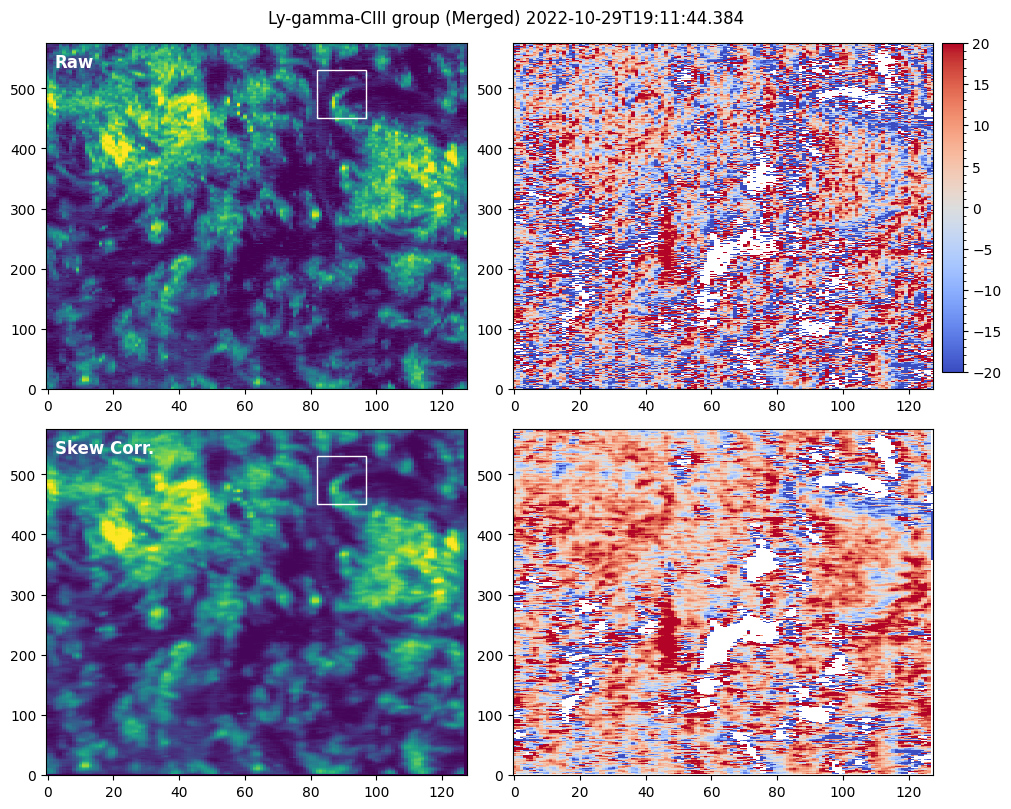

In [30]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10,8), layout="constrained")

ax1.imshow(raw_CIII_int,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(raw_CIII_int, 0.5),
                               vmax=np.nanpercentile(raw_CIII_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im2 = ax2.imshow(raw_CIII_vel,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax3.imshow(skew_CIII_int,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(skew_CIII_int, 0.5),
                               vmax=np.nanpercentile(skew_CIII_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im4 = ax4.imshow(skew_CIII_vel,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax1.text(0.02, 0.97, "Raw", transform=ax1.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

ax3.text(0.02, 0.97, "Skew Corr.", transform=ax3.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

clb, clb_ax = plot_colorbar(im2, ax2, bbox_to_anchor=[1.02, 0.05, 0.05, 0.95])

fig.suptitle(spice_CIII_header['EXTNAME'] + " " +spice_CIII_header['DATE-BEG'], fontsize=12)

# for ax_ in (ax1,ax2):
#     ax_.axhline(330, color="grey", alpha=0.6, ls="--")
#     ax_.axhline(350, color="grey", alpha=0.6, ls="--")

# for ax_ in (ax3,ax4):
#     ax_.contour(skew_CIII_int, [np.nanpercentile(skew_CIII_int, 80)], linewidths=0.5, alpha=0.8, colors="black")

for ax_ in (ax1,ax3):
    jet_box = Rectangle((82,450), 15, 80, fc="none", ec="white")
    ax_.add_patch(jet_box)



In [31]:
spice_CIII_wcs = WCS(remove_temporal_axis(spice_CIII_header)).celestial
spice_CIII_wcs

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
Set MJD-OBS to 59881.799819 from DATE-OBS.
Set MJD-BEG to 59881.799819 from DATE-BEG.
Set MJD-AVG to 59881.803745 from DATE-AVG.
Set MJD-END to 59881.807668 from DATE-END'. [astropy.wcs.wcs]


WCS Keywords

Number of WCS axes: 2
CTYPE : 'HPLN-TAN' 'HPLT-TAN' 
CRVAL : 0.21880141877833334 0.14272717884555555 
CRPIX : 64.5 416.5 
PC1_1 PC1_2  : 0.999006068707 -0.00815711017497 
PC2_1 PC2_2  : 0.243575806234 0.999006068707 
CDELT : 0.0016666666666666666 0.00030500000000000004 
NAXIS : 128  832

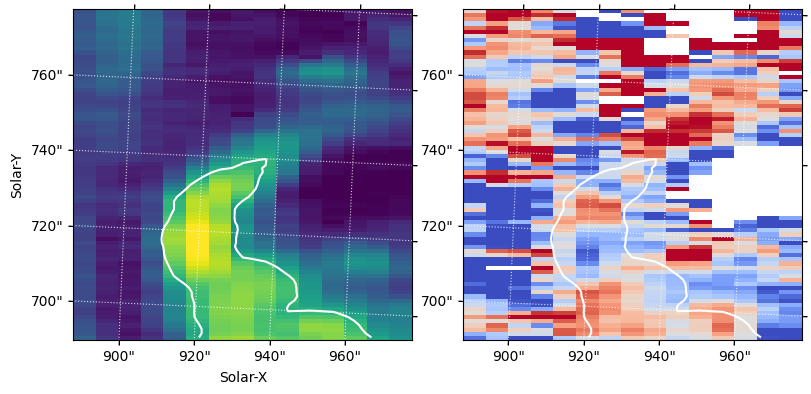

In [32]:
fig = plt.figure(figsize=(8,4), layout="constrained")
ax1 = fig.add_subplot(121, projection=spice_CIII_wcs[450+raw_results_CIII['ymin']:450+80+raw_results_CIII['ymin'], 82:82+15])
ax1.imshow(skew_CIII_int[450:450+80, 82:82+15],
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(skew_CIII_int[450:450+80, 82:82+15], 0.5),
                               vmax=np.nanpercentile(skew_CIII_int[450:450+80, 82:82+15], 99.5),
                               stretch=AsinhStretch(0.1)))
ax2 = fig.add_subplot(122, projection=spice_CIII_wcs[450+raw_results_CIII['ymin']:450+80+raw_results_CIII['ymin'], 82:82+15])
im2 = ax2.imshow(skew_CIII_vel[450:450+80, 82:82+15],
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

for ax_ in (ax1,ax2):
    ax_.contour(skew_CIII_int[450:450+80, 82:82+15], levels=[20], colors="white")

ax1.coords[0].set_axislabel("Solar-X")
ax1.coords[1].set_axislabel("Solar-Y")
ax2.coords[0].set_axislabel("")
ax2.coords[1].set_axislabel("")
ax1.coords.grid(color="white", lw=0.8, ls=":", alpha=0.8)
ax2.coords.grid(color="white", lw=0.8, ls=":", alpha=0.8)

Text(0.5, 0.98, 'Raw')

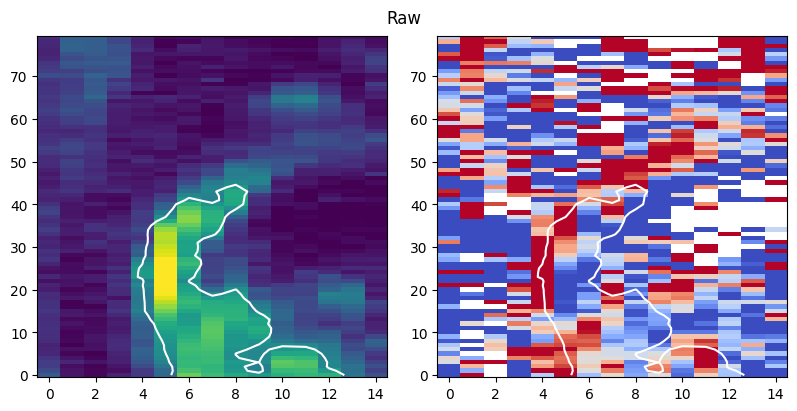

In [33]:
fig = plt.figure(figsize=(8,4), layout="constrained")
ax1 = fig.add_subplot(121, )
ax1.imshow(raw_CIII_int[450:450+80, 82:82+15],
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(raw_CIII_int[450:450+80, 82:82+15], 0.5),
                               vmax=np.nanpercentile(raw_CIII_int[450:450+80, 82:82+15], 99.5),
                               stretch=AsinhStretch(0.1)))
ax2 = fig.add_subplot(122, )
im2 = ax2.imshow(raw_CIII_vel[450:450+80, 82:82+15],
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

for ax_ in (ax1,ax2):
    ax_.contour(raw_CIII_int[450:450+80, 82:82+15], levels=[20], colors="white")

fig.suptitle("Raw")

Text(0.5, 0.98, 'Skew corr.')

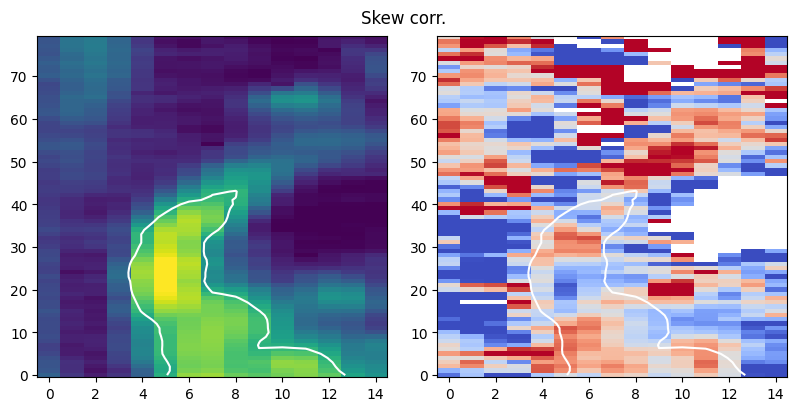

In [34]:
fig = plt.figure(figsize=(8,4), layout="constrained")
ax1 = fig.add_subplot(121, )
ax1.imshow(skew_CIII_int[450:450+80, 82:82+15],
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(skew_CIII_int[450:450+80, 82:82+15], 0.5),
                               vmax=np.nanpercentile(skew_CIII_int[450:450+80, 82:82+15], 99.5),
                               stretch=AsinhStretch(0.1)))
ax2 = fig.add_subplot(122, )
im2 = ax2.imshow(skew_CIII_vel[450:450+80, 82:82+15],
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

for ax_ in (ax1,ax2):
    ax_.contour(skew_CIII_int[450:450+80, 82:82+15], levels=[20], colors="white")

fig.suptitle("Skew corr.")

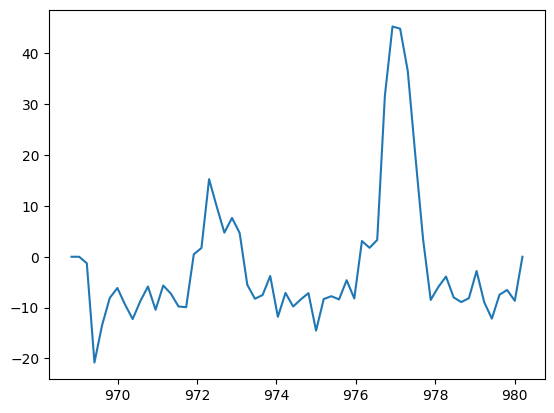

In [69]:
plt.plot(CIII_wvl, np.nansum(best_correction_results_CIII['dat_skew'][82+1, 450+20:450+35,:], axis=0))

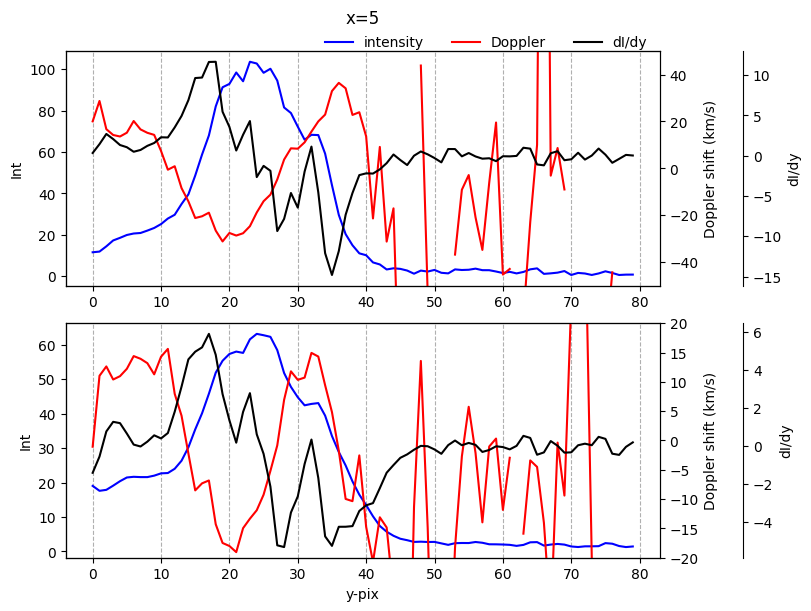

In [64]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(8,6), layout="constrained")

ln1 = ax1.plot(raw_CIII_int[450:450+80, 82+5], color="blue", label="intensity")
ax1_right = ax1.twinx()
ln2 = ax1_right.plot(raw_CIII_vel[450:450+80, 82+5], color="red", label="Doppler")
ax1_right.set_ylim(-50,50)
ax1_right_2 = ax1.twinx()
ln3 = ax1_right_2.plot(np.gradient(raw_CIII_int[450:450+80, 82+5]), color="black", label="dI/dy")
ax1_right_2.spines['right'].set_position(('outward', 60))
ax1.grid(which='major', axis='x', linestyle='--')
ax1.set_ylabel("Int")
ax1_right.set_ylabel("Doppler shift (km/s)")
ax1_right_2.set_ylabel("dI/dy")

ax2.plot(skew_CIII_int[450:450+80, 82+5], color="blue")
ax2_right = ax2.twinx()
ax2_right.plot(skew_CIII_vel[450:450+80, 82+5], color="red")
ax2_right.set_ylim(-20,20)
ax2_right_2 = ax2.twinx()
ax2_right_2.plot(np.gradient(skew_CIII_int[450:450+80, 82+5]), color="black", label="dI/dy")
ax2_right_2.spines['right'].set_position(('outward', 60))
ax2.grid(which='major', axis='x', linestyle='--')
ax2.set_ylabel("Int")
ax2_right.set_ylabel("Doppler shift (km/s)")
ax2_right_2.set_ylabel("dI/dy")
ax2.set_xlabel("y-pix")

ax1.set_title("x=5", pad=20)
ax1.legend([ln1[0], ln2[0], ln3[0]], [ln1[0].get_label(), ln2[0].get_label(), ln3[0].get_label()],frameon=False,
            bbox_to_anchor=[0, 1.02, 1, 0.1], ncols=3)

In [34]:
test_skew_x_CIII, test_skew_y_CIII = 1.1, -2.2


test_correction_results_CIII = full_correction(spice_CIII_data, spice_CIII_header, test_skew_x_CIII, test_skew_y_CIII, nthreads=12,
                                               linelist={'C III 977':977.0})

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


In [35]:
test_CIII_int = test_correction_results_CIII['linefits']['Ly-gamma-CIII group (Merged)']['C III 977']['amplitudes'].data[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T
test_CIII_vel = detrend_dopp(test_correction_results_CIII['linefits']['Ly-gamma-CIII group (Merged)']['C III 977']['centers'])[:,raw_results_CIII['ymin']:raw_results_CIII['ymax']].T
test_CIII_vel_err = test_correction_results_CIII['linefits']['Ly-gamma-CIII group (Merged)']['C III 977']['centers'].uncertainty.array[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T

test_CIII_vel_mask = np.abs(test_CIII_vel_err) > 0.025
test_CIII_vel[test_CIII_vel_mask] = np.nan
test_CIII_vel = test_CIII_vel - np.nanmedian(test_CIII_vel[:200, :40]) 
test_CIII_vel = test_CIII_vel/977.020*const.c.to_value(u.km/u.s) + 5

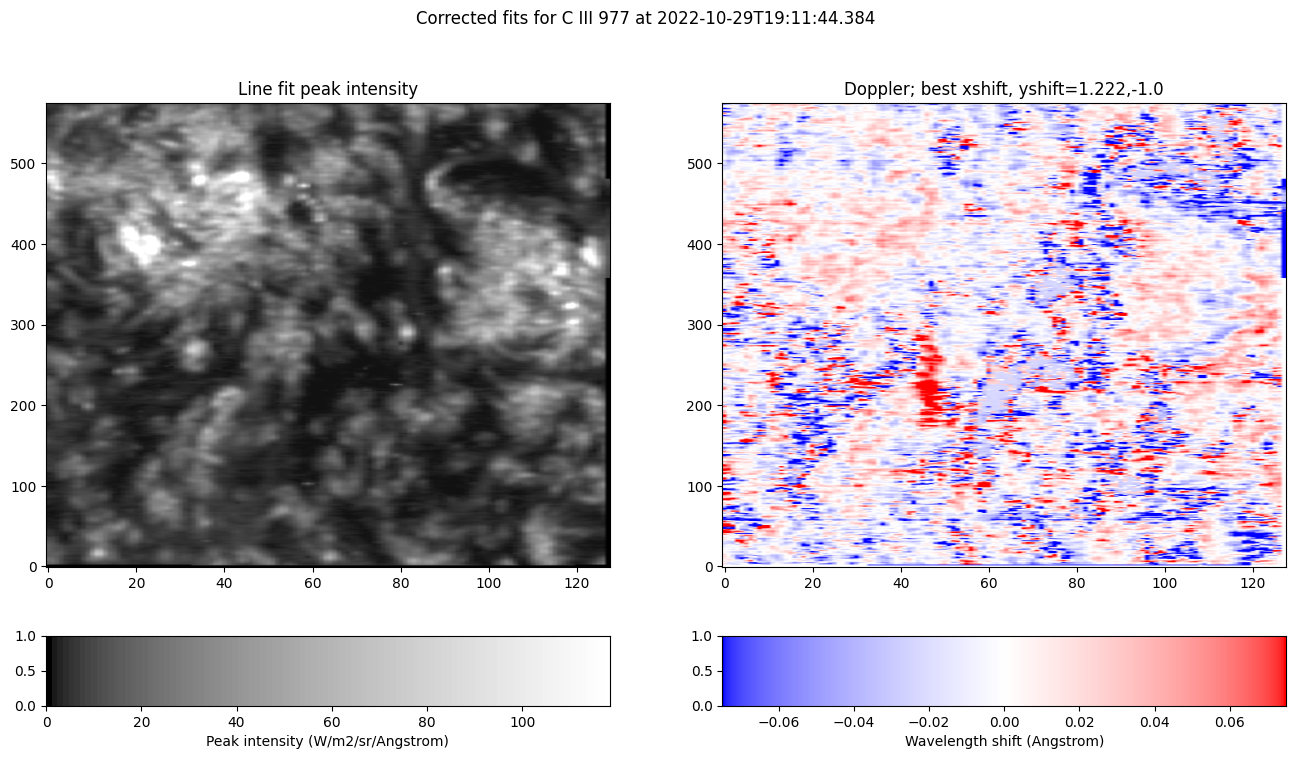

In [36]:
correction_preview(best_correction_results_CIII)

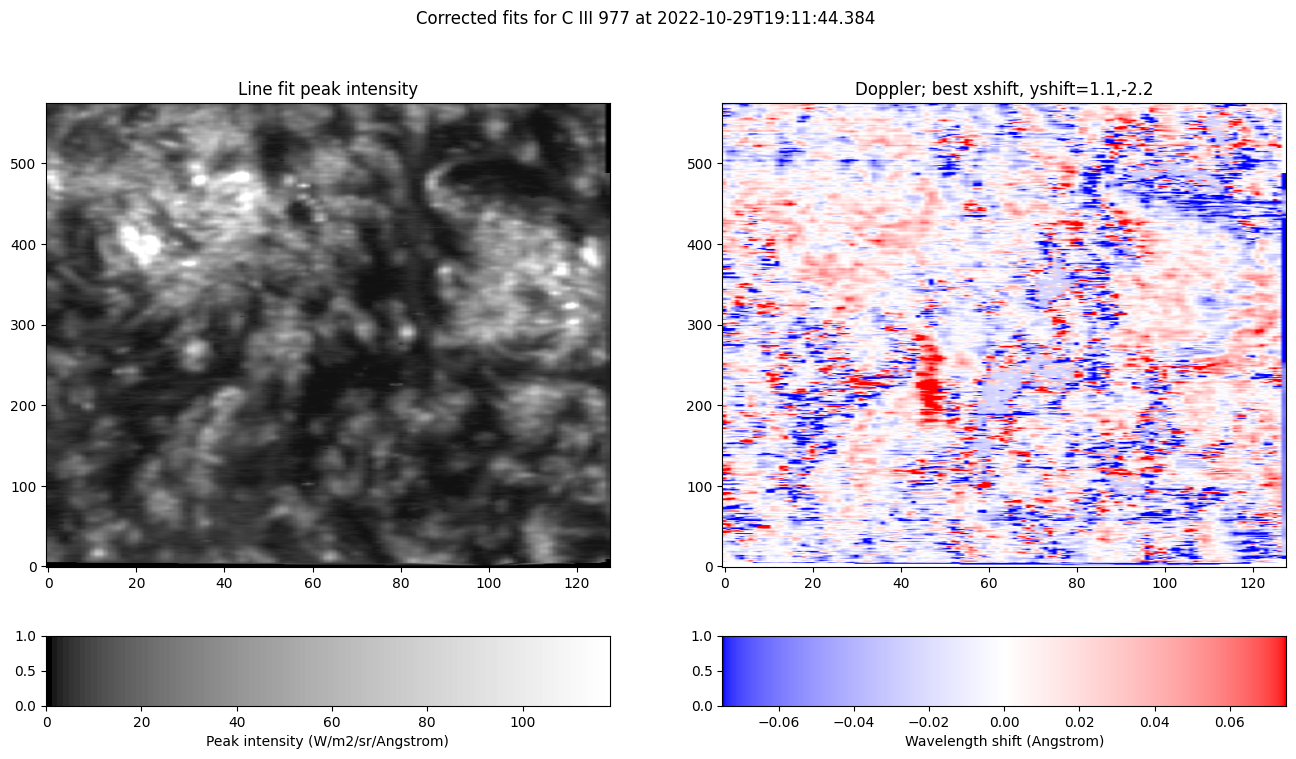

In [37]:
correction_preview(test_correction_results_CIII, load_data=False)

Text(0.5, 0.98, 'Skew corr. (1.22, -2)')

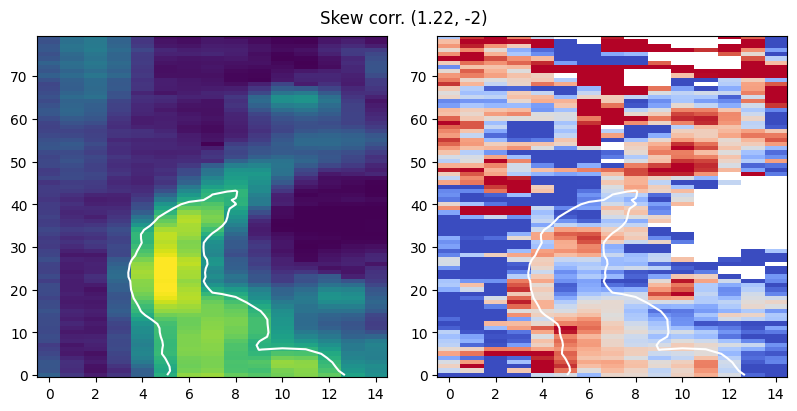

In [42]:
fig = plt.figure(figsize=(8,4), layout="constrained")
ax1 = fig.add_subplot(121, )
ax1.imshow(test_CIII_int[450:450+80, 82:82+15],
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(test_CIII_int[450:450+80, 82:82+15], 0.5),
                               vmax=np.nanpercentile(test_CIII_int[450:450+80, 82:82+15], 99.5),
                               stretch=AsinhStretch(0.1)))
ax2 = fig.add_subplot(122, )
im2 = ax2.imshow(test_CIII_vel[450:450+80, 82:82+15],
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

for ax_ in (ax1,ax2):
    ax_.contour(test_CIII_int[450:450+80, 82:82+15], levels=[20], colors="white")

fig.suptitle("Skew corr. (1.22, -2)")

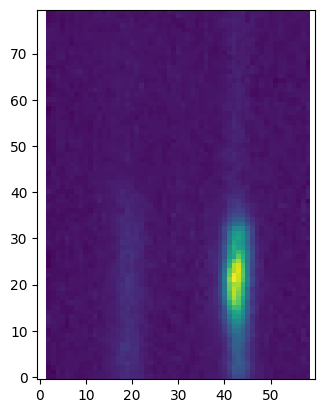

In [89]:
plt.imshow(best_correction_results_CIII['dat_skew'][82+5, 450 + raw_results_CIII['ymin']:450 + raw_results_CIII['ymin']+80], origin="lower",
          )

In [35]:
if not load_data:
    raw_NeVIII_int = raw_results_NeVIII['linefits']['N IV 765 - SH - Comp 8 ... Ne VIII 770 - LH - Comp 8 (Merged)']['Ne VIII 770']['amplitudes'].data[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
    raw_NeVIII_vel = detrend_dopp(raw_results_NeVIII['linefits']['N IV 765 - SH - Comp 8 ... Ne VIII 770 - LH - Comp 8 (Merged)']['Ne VIII 770']['centers'])[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax']].T
    raw_NeVIII_vel_err = raw_results_NeVIII['linefits']['N IV 765 - SH - Comp 8 ... Ne VIII 770 - LH - Comp 8 (Merged)']['Ne VIII 770']['centers'].uncertainty.array[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T


    skew_NeVIII_int = best_correction_results_NeVIII['linefits']['N IV 765 - SH - Comp 8 ... Ne VIII 770 - LH - Comp 8 (Merged)']['Ne VIII 770']['amplitudes'].data[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
    skew_NeVIII_vel = detrend_dopp(best_correction_results_NeVIII['linefits']['N IV 765 - SH - Comp 8 ... Ne VIII 770 - LH - Comp 8 (Merged)']['Ne VIII 770']['centers'])[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax']].T
    skew_NeVIII_vel_err = best_correction_results_NeVIII['linefits']['N IV 765 - SH - Comp 8 ... Ne VIII 770 - LH - Comp 8 (Merged)']['Ne VIII 770']['centers'].uncertainty.array[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
else:
    raw_NeVIII_linefits = raw_results_NeVIII['linefits'].item()
    raw_results_NeVIII_ymin = raw_results_NeVIII['ymin'].item()
    raw_results_NeVIII_ymax = raw_results_NeVIII['ymax'].item()

    raw_NeVIII_int = raw_NeVIII_linefits[0][0]['amplitudes'].data[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T
    raw_NeVIII_vel = detrend_dopp(raw_NeVIII_linefits[0][0]['centers'])[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax].T
    raw_NeVIII_vel_err = raw_NeVIII_linefits[0][0]['centers'].uncertainty.array[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T

    skew_NeVIII_linefits = best_correction_results_NeVIII['linefits'].item()

    skew_NeVIII_int = skew_NeVIII_linefits[0][0]['amplitudes'].data[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T
    skew_NeVIII_vel = detrend_dopp(skew_NeVIII_linefits[0][0]['centers'])[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax].T
    skew_NeVIII_vel_err = skew_NeVIII_linefits[0][0]['centers'].uncertainty.array[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T  
    

raw_NeVIII_vel_mask = np.abs(raw_NeVIII_vel_err) > 0.05
raw_NeVIII_vel[raw_NeVIII_vel_mask] = np.nan
raw_NeVIII_vel = raw_NeVIII_vel - np.nanmedian(raw_NeVIII_vel[360:380, :]) 
raw_NeVIII_vel = raw_NeVIII_vel/770.428*const.c.to_value(u.km/u.s) - 2.5 # from Xia et al. (2004)

skew_NeVIII_vel_mask = np.abs(skew_NeVIII_vel_err) > 0.05
skew_NeVIII_vel[skew_NeVIII_vel_mask] = np.nan
skew_NeVIII_vel = skew_NeVIII_vel - np.nanmedian(skew_NeVIII_vel[360:380, :])
skew_NeVIII_vel = skew_NeVIII_vel/770.428*const.c.to_value(u.km/u.s) 

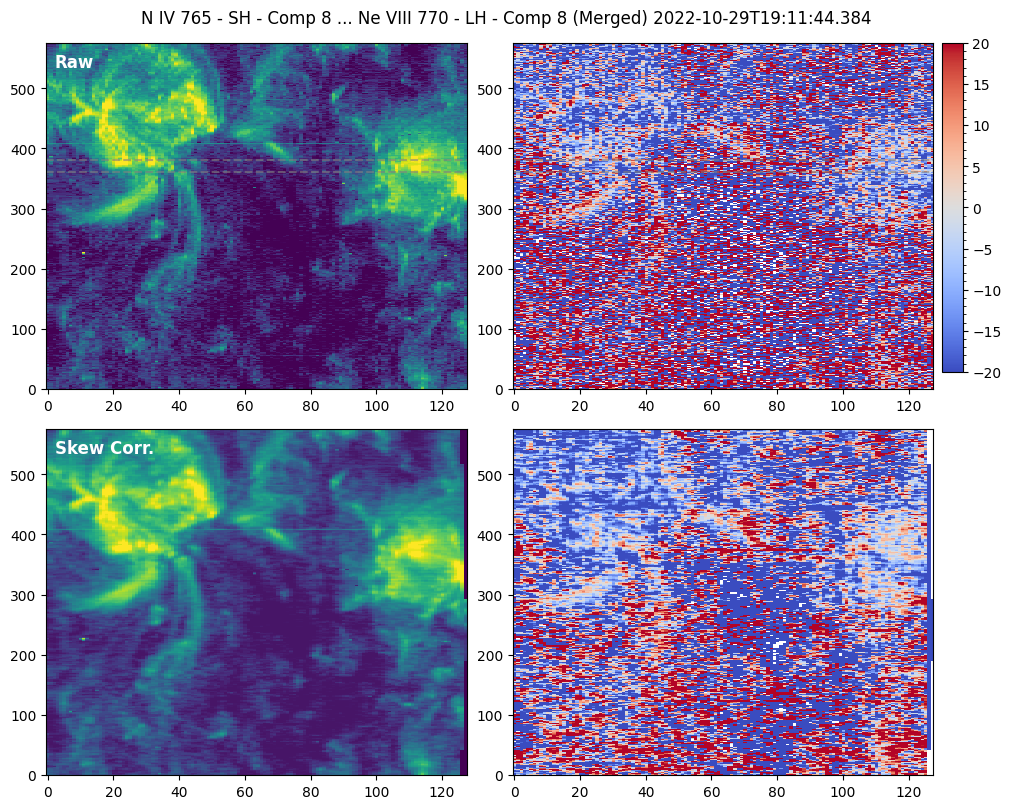

In [34]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10,8), layout="constrained")

ax1.imshow(raw_NeVIII_int,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(raw_NeVIII_int, 0.5),
                               vmax=np.nanpercentile(raw_NeVIII_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im2 = ax2.imshow(raw_NeVIII_vel,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax3.imshow(skew_NeVIII_int,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(skew_NeVIII_int, 0.5),
                               vmax=np.nanpercentile(skew_NeVIII_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im4 = ax4.imshow(skew_NeVIII_vel,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax1.text(0.02, 0.97, "Raw", transform=ax1.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

ax3.text(0.02, 0.97, "Skew Corr.", transform=ax3.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

clb, clb_ax = plot_colorbar(im2, ax2, bbox_to_anchor=[1.02, 0.05, 0.05, 0.95])

fig.suptitle(spice_NeVIII_header['EXTNAME'] + " " +spice_NeVIII_header['DATE-BEG'], fontsize=12)

